# SVM Classification — 4QMV Features

Pipeline:
1. Load `poc_abs_quadran_sum.xlsx` (per-frame)
2. Pisahkan external test set (per-subject)
3. Train SVM via `build_svm()` — Pipeline(Scaler → SVM balanced)
4. Split 60/40, 70/30, 80/20, 90/10
5. Metrik: UF1 (macro F1), UAR (macro recall), accuracy
6. External test


In [1]:
import sys, os
from pathlib import Path

ROOT = Path(os.getcwd()).resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent.parent
elif ROOT.name == "comparasion":
    ROOT = ROOT.parent
elif ROOT.name in {"lstm", "svm", "knn"}:
    ROOT = ROOT.parent.parent.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"Project root: {ROOT}")

Project root: /home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from comparasion.core.models import build_svm, fit_model, predict


## 1. Load Data

In [3]:
FEATURE_PATH = Path("comparasion/output_casme2/features/poc_abs_quadran_sum.xlsx")

df = pd.read_excel(FEATURE_PATH)
print(f"Shape: {df.shape}")

META_COLS = ["emotion", "subject", "clip", "frame", "label"]
feat_cols = [c for c in df.columns if c not in META_COLS]

print(f"Features: {len(feat_cols)}")
print(f"\nLabel dist:")
print(df["label"].value_counts())

Shape: (1151, 145)
Features: 140

Label dist:
label
Surprise     324
Happiness    305
Sadness      267
Disgust      255
Name: count, dtype: int64


## 2. External Test Set

Pisahkan 2 subject per emotion → external test. Sisanya = main (train+val).


In [4]:
SEED = 42

le = LabelEncoder()
df["label_enc"] = le.fit_transform(df["label"])
print(f"Classes: {list(le.classes_)}")

rng = np.random.RandomState(SEED)
external_subjects = set()

for emo in df["emotion"].unique():
    subjects_in_emo = df[df["emotion"] == emo]["subject"].unique()
    n_ext = min(2, len(subjects_in_emo))
    chosen = rng.choice(subjects_in_emo, size=n_ext, replace=False)
    external_subjects.update(chosen)

print(f"External subjects ({len(external_subjects)}): {sorted(external_subjects)}")

df_ext = df[df["subject"].isin(external_subjects)].copy()
df_main = df[~df["subject"].isin(external_subjects)].copy()

print(f"\nMain: {len(df_main)} rows")
print(f"External: {len(df_ext)} rows")
print(f"\nMain label dist:")
print(df_main["label"].value_counts())

Classes: ['Disgust', 'Happiness', 'Sadness', 'Surprise']
External subjects (7): [np.int64(5), np.int64(6), np.int64(14), np.int64(17), np.int64(19), np.int64(20), np.int64(24)]

Main: 344 rows
External: 807 rows

Main label dist:
label
Happiness    145
Disgust      115
Surprise      45
Sadness       39
Name: count, dtype: int64


In [5]:
X_main = df_main[feat_cols].values
y_main = df_main["label_enc"].values

X_ext = df_ext[feat_cols].values
y_ext = df_ext["label_enc"].values

print(f"X_main: {X_main.shape}")
print(f"X_ext:  {X_ext.shape}")

X_main: (344, 140)
X_ext:  (807, 140)


## 3. Training — Tiap Split Terpisah


### Split 60/40

In [6]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_main, y_main, test_size=0.4, stratify=y_main, random_state=SEED
)

pipe = build_svm()
res = fit_model(pipe, X_tr, y_tr, model_name="SVM_4QMV_4QMV_60/40")

y_tr_pred = predict(res.model, X_tr)
y_val_pred = predict(res.model, X_val)

train_acc = accuracy_score(y_tr, y_tr_pred)
val_acc = accuracy_score(y_val, y_val_pred)
train_f1 = f1_score(y_tr, y_tr_pred, average="macro")
val_f1 = f1_score(y_val, y_val_pred, average="macro")
train_uar = recall_score(y_tr, y_tr_pred, average="macro")
val_uar = recall_score(y_val, y_val_pred, average="macro")

print(f"Train: {len(X_tr)} rows, Val: {len(X_val)} rows")
print(f"Train — Acc: {train_acc:.4f}  UF1: {train_f1:.4f}  UAR: {train_uar:.4f}")
print(f"Val   — Acc: {val_acc:.4f}  UF1: {val_f1:.4f}  UAR: {val_uar:.4f}")
print(f"\n{classification_report(y_val, y_val_pred, target_names=le.classes_)}")

result_60_40 = {
    "split": "60/40", "test_size": 0.4,
    "train_acc": train_acc, "val_acc": val_acc,
    "train_f1": train_f1, "val_f1": val_f1,
    "train_uar": train_uar, "val_uar": val_uar,
    "model": res.model,
    "y_val": y_val, "y_val_pred": y_val_pred,
}

Train: 206 rows, Val: 138 rows
Train — Acc: 0.9272  UF1: 0.9271  UAR: 0.9460
Val   — Acc: 0.7464  UF1: 0.7609  UAR: 0.7894

              precision    recall  f1-score   support

     Disgust       0.77      0.65      0.71        46
   Happiness       0.80      0.74      0.77        58
     Sadness       0.93      0.88      0.90        16
    Surprise       0.53      0.89      0.67        18

    accuracy                           0.75       138
   macro avg       0.76      0.79      0.76       138
weighted avg       0.77      0.75      0.75       138



### Split 70/30

In [7]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_main, y_main, test_size=0.3, stratify=y_main, random_state=SEED
)

pipe = build_svm()
res = fit_model(pipe, X_tr, y_tr, model_name="SVM_4QMV_4QMV_70/30")

y_tr_pred = predict(res.model, X_tr)
y_val_pred = predict(res.model, X_val)

train_acc = accuracy_score(y_tr, y_tr_pred)
val_acc = accuracy_score(y_val, y_val_pred)
train_f1 = f1_score(y_tr, y_tr_pred, average="macro")
val_f1 = f1_score(y_val, y_val_pred, average="macro")
train_uar = recall_score(y_tr, y_tr_pred, average="macro")
val_uar = recall_score(y_val, y_val_pred, average="macro")

print(f"Train: {len(X_tr)} rows, Val: {len(X_val)} rows")
print(f"Train — Acc: {train_acc:.4f}  UF1: {train_f1:.4f}  UAR: {train_uar:.4f}")
print(f"Val   — Acc: {val_acc:.4f}  UF1: {val_f1:.4f}  UAR: {val_uar:.4f}")
print(f"\n{classification_report(y_val, y_val_pred, target_names=le.classes_)}")

result_70_30 = {
    "split": "70/30", "test_size": 0.3,
    "train_acc": train_acc, "val_acc": val_acc,
    "train_f1": train_f1, "val_f1": val_f1,
    "train_uar": train_uar, "val_uar": val_uar,
    "model": res.model,
    "y_val": y_val, "y_val_pred": y_val_pred,
}

Train: 240 rows, Val: 104 rows
Train — Acc: 0.9208  UF1: 0.9195  UAR: 0.9418
Val   — Acc: 0.7308  UF1: 0.7514  UAR: 0.7689

              precision    recall  f1-score   support

     Disgust       0.76      0.71      0.74        35
   Happiness       0.75      0.68      0.71        44
     Sadness       1.00      0.83      0.91        12
    Surprise       0.52      0.85      0.65        13

    accuracy                           0.73       104
   macro avg       0.76      0.77      0.75       104
weighted avg       0.75      0.73      0.74       104



### Split 80/20

In [8]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_main, y_main, test_size=0.2, stratify=y_main, random_state=SEED
)

pipe = build_svm()
res = fit_model(pipe, X_tr, y_tr, model_name="SVM_4QMV_4QMV_80/20")

y_tr_pred = predict(res.model, X_tr)
y_val_pred = predict(res.model, X_val)

train_acc = accuracy_score(y_tr, y_tr_pred)
val_acc = accuracy_score(y_val, y_val_pred)
train_f1 = f1_score(y_tr, y_tr_pred, average="macro")
val_f1 = f1_score(y_val, y_val_pred, average="macro")
train_uar = recall_score(y_tr, y_tr_pred, average="macro")
val_uar = recall_score(y_val, y_val_pred, average="macro")

print(f"Train: {len(X_tr)} rows, Val: {len(X_val)} rows")
print(f"Train — Acc: {train_acc:.4f}  UF1: {train_f1:.4f}  UAR: {train_uar:.4f}")
print(f"Val   — Acc: {val_acc:.4f}  UF1: {val_f1:.4f}  UAR: {val_uar:.4f}")
print(f"\n{classification_report(y_val, y_val_pred, target_names=le.classes_)}")

result_80_20 = {
    "split": "80/20", "test_size": 0.2,
    "train_acc": train_acc, "val_acc": val_acc,
    "train_f1": train_f1, "val_f1": val_f1,
    "train_uar": train_uar, "val_uar": val_uar,
    "model": res.model,
    "y_val": y_val, "y_val_pred": y_val_pred,
}

Train: 275 rows, Val: 69 rows
Train — Acc: 0.9091  UF1: 0.9118  UAR: 0.9335
Val   — Acc: 0.7101  UF1: 0.7353  UAR: 0.7519

              precision    recall  f1-score   support

     Disgust       0.69      0.78      0.73        23
   Happiness       0.74      0.59      0.65        29
     Sadness       1.00      0.75      0.86         8
    Surprise       0.57      0.89      0.70         9

    accuracy                           0.71        69
   macro avg       0.75      0.75      0.74        69
weighted avg       0.73      0.71      0.71        69



### Split 90/10

In [9]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_main, y_main, test_size=0.1, stratify=y_main, random_state=SEED
)

pipe = build_svm()
res = fit_model(pipe, X_tr, y_tr, model_name="SVM_4QMV_4QMV_90/10")

y_tr_pred = predict(res.model, X_tr)
y_val_pred = predict(res.model, X_val)

train_acc = accuracy_score(y_tr, y_tr_pred)
val_acc = accuracy_score(y_val, y_val_pred)
train_f1 = f1_score(y_tr, y_tr_pred, average="macro")
val_f1 = f1_score(y_val, y_val_pred, average="macro")
train_uar = recall_score(y_tr, y_tr_pred, average="macro")
val_uar = recall_score(y_val, y_val_pred, average="macro")

print(f"Train: {len(X_tr)} rows, Val: {len(X_val)} rows")
print(f"Train — Acc: {train_acc:.4f}  UF1: {train_f1:.4f}  UAR: {train_uar:.4f}")
print(f"Val   — Acc: {val_acc:.4f}  UF1: {val_f1:.4f}  UAR: {val_uar:.4f}")
print(f"\n{classification_report(y_val, y_val_pred, target_names=le.classes_)}")

result_90_10 = {
    "split": "90/10", "test_size": 0.1,
    "train_acc": train_acc, "val_acc": val_acc,
    "train_f1": train_f1, "val_f1": val_f1,
    "train_uar": train_uar, "val_uar": val_uar,
    "model": res.model,
    "y_val": y_val, "y_val_pred": y_val_pred,
}

Train: 309 rows, Val: 35 rows
Train — Acc: 0.9126  UF1: 0.9158  UAR: 0.9368
Val   — Acc: 0.8286  UF1: 0.8319  UAR: 0.8458

              precision    recall  f1-score   support

     Disgust       0.83      0.83      0.83        12
   Happiness       0.86      0.80      0.83        15
     Sadness       1.00      1.00      1.00         4
    Surprise       0.60      0.75      0.67         4

    accuracy                           0.83        35
   macro avg       0.82      0.85      0.83        35
weighted avg       0.84      0.83      0.83        35



In [10]:
results = [result_60_40, result_70_30, result_80_20, result_90_10]

## 4. Tabel Perbandingan

In [11]:
comparison = pd.DataFrame([{
    "Split": r["split"],
    "Train Acc": f'{r["train_acc"]:.4f}',
    "Val Acc": f'{r["val_acc"]:.4f}',
    "Train UF1": f'{r["train_f1"]:.4f}',
    "Val UF1": f'{r["val_f1"]:.4f}',
    "Train UAR": f'{r["train_uar"]:.4f}',
    "Val UAR": f'{r["val_uar"]:.4f}',
} for r in results])

print(comparison.to_string(index=False))
comparison

Split Train Acc Val Acc Train UF1 Val UF1 Train UAR Val UAR
60/40    0.9272  0.7464    0.9271  0.7609    0.9460  0.7894
70/30    0.9208  0.7308    0.9195  0.7514    0.9418  0.7689
80/20    0.9091  0.7101    0.9118  0.7353    0.9335  0.7519
90/10    0.9126  0.8286    0.9158  0.8319    0.9368  0.8458


,Split,Train Acc,Val Acc,Train UF1,Val UF1,Train UAR,Val UAR
0,60/40,0.9272,0.7464,0.9271,0.7609,0.9460,0.7894
1,70/30,0.9208,0.7308,0.9195,0.7514,0.9418,0.7689
2,80/20,0.9091,0.7101,0.9118,0.7353,0.9335,0.7519
3,90/10,0.9126,0.8286,0.9158,0.8319,0.9368,0.8458


## 5. Confusion Matrix per Split

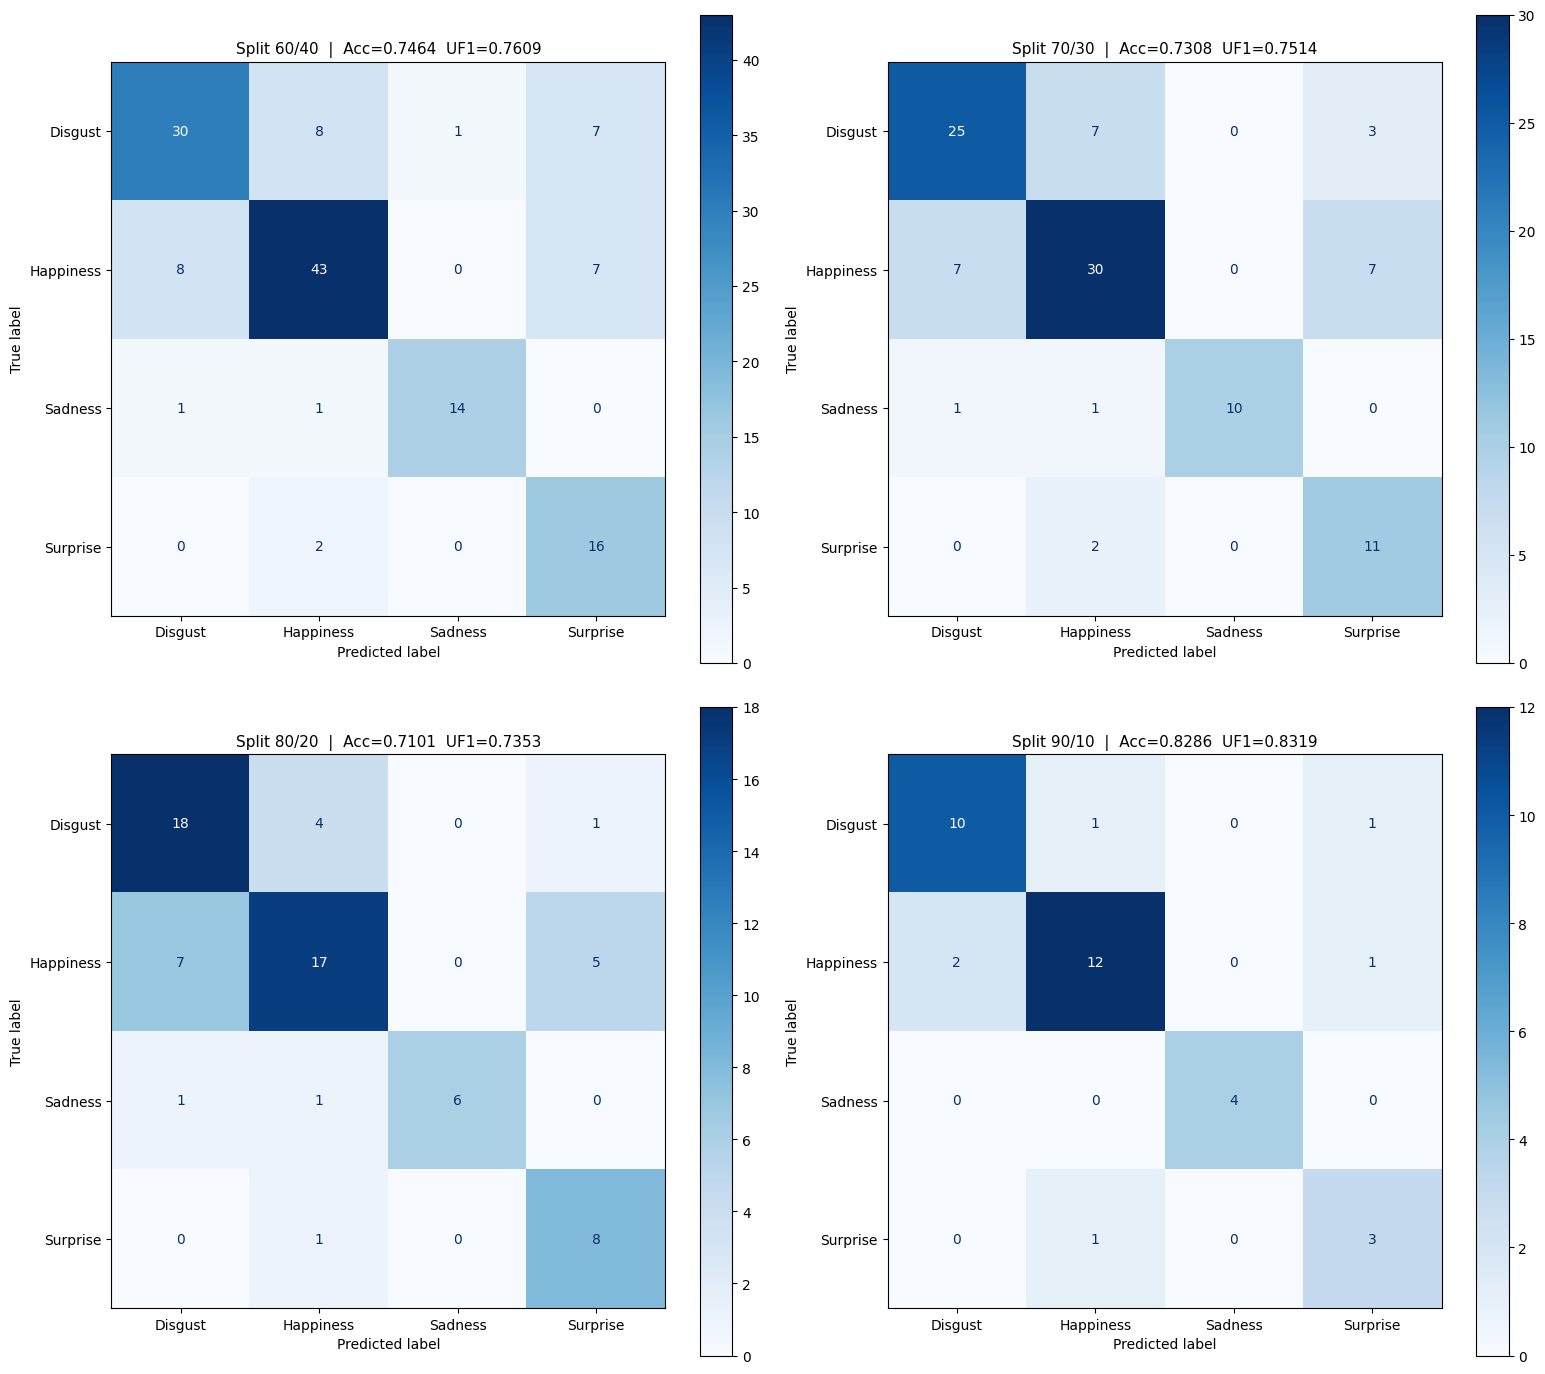

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
for ax, r in zip(axes.flatten(), results):
    cm = confusion_matrix(r["y_val"], r["y_val_pred"])
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title(f'Split {r["split"]}  |  Acc={r["val_acc"]:.4f}  UF1={r["val_f1"]:.4f}', fontsize=11)
plt.tight_layout()
plt.show()

## 6. Best Split

In [13]:
best = max(results, key=lambda r: r["val_f1"])
print(f"Best split: {best['split']} (Val UF1={best['val_f1']:.4f})\n")
print(classification_report(best["y_val"], best["y_val_pred"], target_names=le.classes_))

Best split: 90/10 (Val UF1=0.8319)

              precision    recall  f1-score   support

     Disgust       0.83      0.83      0.83        12
   Happiness       0.86      0.80      0.83        15
     Sadness       1.00      1.00      1.00         4
    Surprise       0.60      0.75      0.67         4

    accuracy                           0.83        35
   macro avg       0.82      0.85      0.83        35
weighted avg       0.84      0.83      0.83        35



## 7. External Test

In [14]:
y_ext_pred = predict(best["model"], X_ext)

ext_acc = accuracy_score(y_ext, y_ext_pred)
ext_f1 = f1_score(y_ext, y_ext_pred, average="macro")
ext_uar = recall_score(y_ext, y_ext_pred, average="macro")

print(f"External Test — Acc: {ext_acc:.4f}  UF1: {ext_f1:.4f}  UAR: {ext_uar:.4f}")
print(f"\n{classification_report(y_ext, y_ext_pred, target_names=le.classes_)}")

External Test — Acc: 0.3408  UF1: 0.3472  UAR: 0.3709

              precision    recall  f1-score   support

     Disgust       0.22      0.50      0.31       140
   Happiness       0.24      0.41      0.30       160
     Sadness       0.75      0.40      0.52       228
    Surprise       0.52      0.17      0.26       279

    accuracy                           0.34       807
   macro avg       0.43      0.37      0.35       807
weighted avg       0.48      0.34      0.35       807



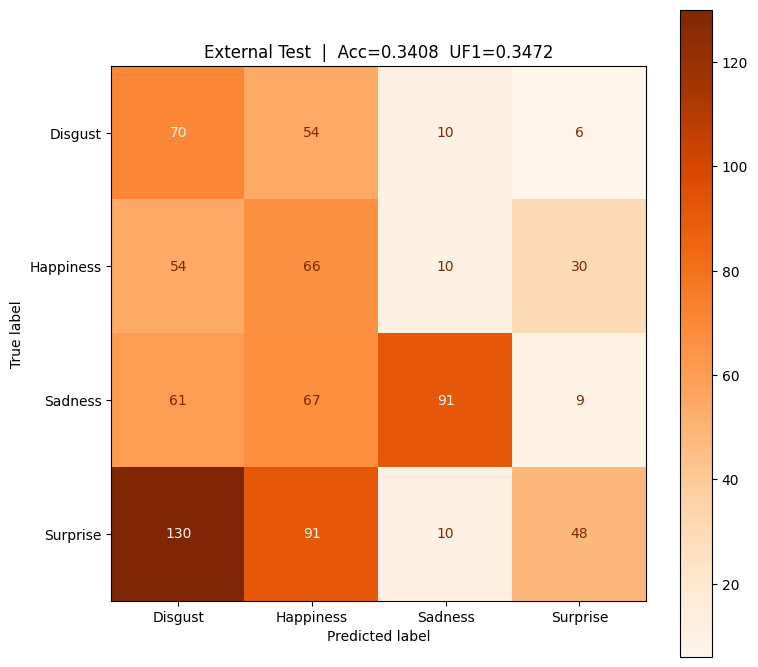

In [15]:
fig, ax = plt.subplots(figsize=(8, 7))
cm_ext = confusion_matrix(y_ext, y_ext_pred)
ConfusionMatrixDisplay(cm_ext, display_labels=le.classes_).plot(ax=ax, cmap="Oranges", values_format="d")
ax.set_title(f"External Test  |  Acc={ext_acc:.4f}  UF1={ext_f1:.4f}", fontsize=12)
plt.tight_layout()
plt.show()

## 8. Ringkasan

In [16]:
summary = pd.DataFrame([{
    "Split": r["split"],
    "Train Acc": f'{r["train_acc"]:.4f}',
    "Val Acc": f'{r["val_acc"]:.4f}',
    "Val UF1": f'{r["val_f1"]:.4f}',
    "Val UAR": f'{r["val_uar"]:.4f}',
} for r in results])

summary = pd.concat([summary, pd.DataFrame([{
    "Split": f"External ({best['split']})",
    "Train Acc": "-",
    "Val Acc": f"{ext_acc:.4f}",
    "Val UF1": f"{ext_f1:.4f}",
    "Val UAR": f"{ext_uar:.4f}",
}])], ignore_index=True)

print(summary.to_string(index=False))
summary

           Split Train Acc Val Acc Val UF1 Val UAR
           60/40    0.9272  0.7464  0.7609  0.7894
           70/30    0.9208  0.7308  0.7514  0.7689
           80/20    0.9091  0.7101  0.7353  0.7519
           90/10    0.9126  0.8286  0.8319  0.8458
External (90/10)         -  0.3408  0.3472  0.3709


,Split,Train Acc,Val Acc,Val UF1,Val UAR
0,60/40,0.9272,0.7464,0.7609,0.7894
1,70/30,0.9208,0.7308,0.7514,0.7689
2,80/20,0.9091,0.7101,0.7353,0.7519
3,90/10,0.9126,0.8286,0.8319,0.8458
4,External (90/10),-,0.3408,0.3472,0.3709
